## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [2]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [3]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [4]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


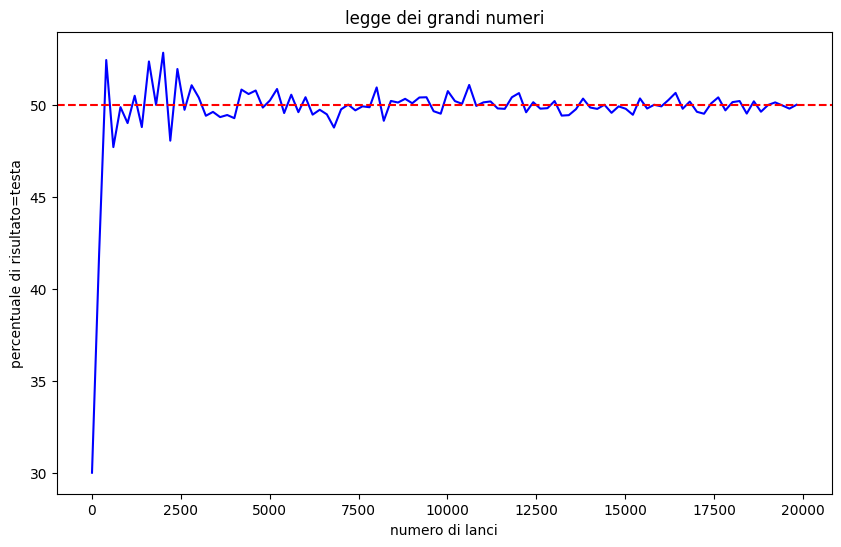

In [5]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [6]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Numero di righe e colonne:
(891, 12)
Valori mancanti per colonna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Valori mancanti in Embarked dopo il riempimento:
0
Numero di righe duplicate:
0
Età media per classe:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64
Valori mancanti in Age dopo il riempimento:
0


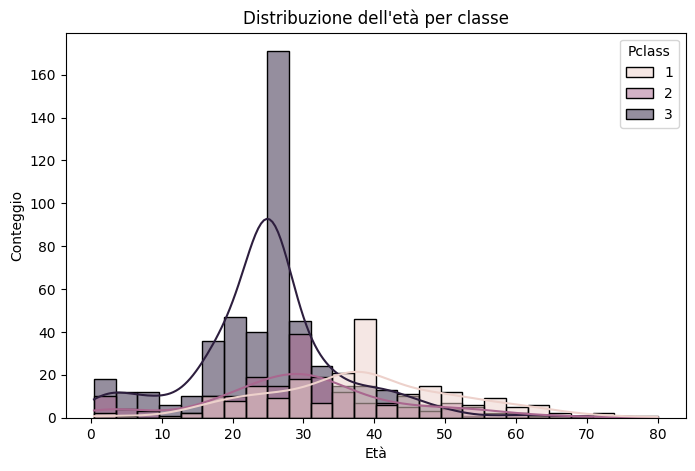

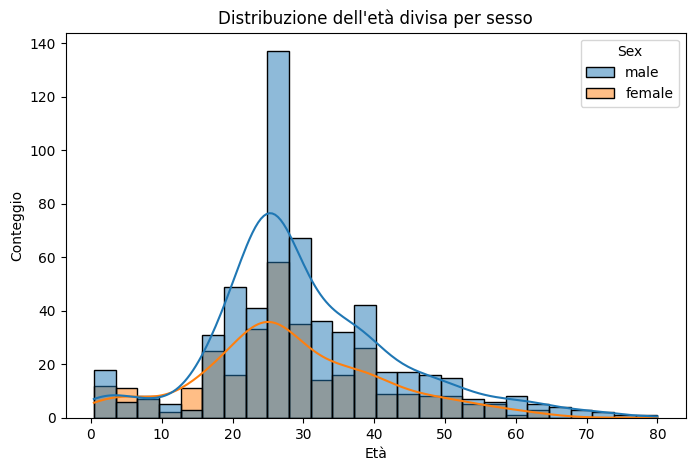

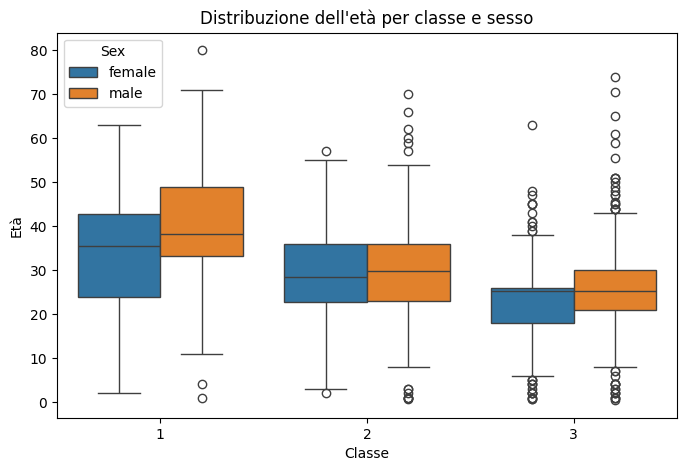

In [7]:
print("Numero di righe e colonne:")
print(df.shape)

print("Valori mancanti per colonna:")
print(df.isnull().sum())

moda_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(moda_embarked)

print("Valori mancanti in Embarked dopo il riempimento:")
print(df["Embarked"].isnull().sum())

print("Numero di righe duplicate:")
print(df.duplicated().sum())

eta_media_per_classe = df.groupby("Pclass")["Age"].mean()
print("Età media per classe:")
print(eta_media_per_classe)

df["Age"] = df.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.mean()))

print("Valori mancanti in Age dopo il riempimento:")
print(df["Age"].isnull().sum())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Pclass", kde=True)
plt.title("Distribuzione dell'età per classe")
plt.xlabel("Età")
plt.ylabel("Conteggio")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Sex", kde=True)
plt.title("Distribuzione dell'età divisa per sesso")
plt.xlabel("Età")
plt.ylabel("Conteggio")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex")
plt.title("Distribuzione dell'età per classe e sesso")
plt.xlabel("Classe")
plt.ylabel("Età")
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Distribuzione delle specie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Lunghezza e larghezza media dei petali per specie:
            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


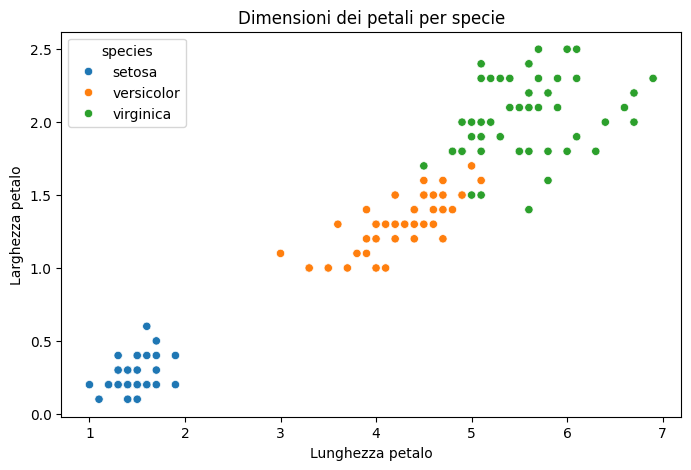

Analisi area del petalo per specie:
            count     mean       std   min     25%     50%    75%    max
species                                                                 
setosa       50.0   0.3656  0.181155  0.11  0.2800   0.300   0.42   0.96
versicolor   50.0   5.7204  1.368403  3.30  4.8600   5.615   6.75   8.64
virginica    50.0  11.2962  2.157412  7.50  9.7175  11.445  12.79  15.87


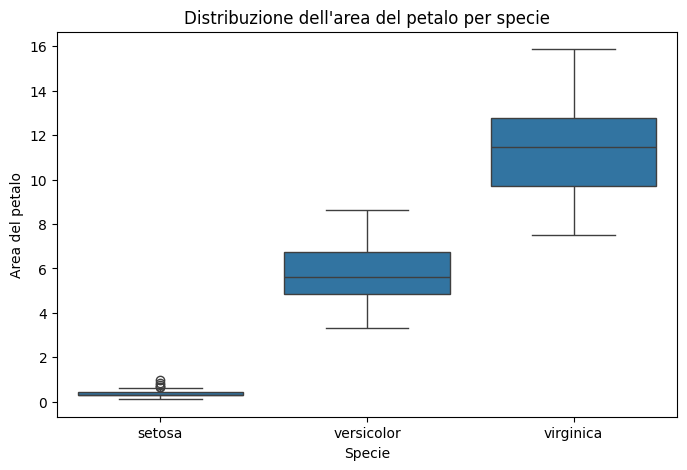

In [9]:
print("Distribuzione delle specie:")
print(df["species"].value_counts())

media_petali = df.groupby("species")[["petal_length", "petal_width"]].mean()

print("Lunghezza e larghezza media dei petali per specie:")
print(media_petali)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Dimensioni dei petali per specie")
plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.show()

df["petal_area"] = df["petal_length"] * df["petal_width"]

print("Analisi area del petalo per specie:")
print(df.groupby("species")["petal_area"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="petal_area")
plt.title("Distribuzione dell'area del petalo per specie")
plt.xlabel("Specie")
plt.ylabel("Area del petalo")
plt.show()